# Experimental Feature Encoding

This notebook starts from the QC-cleaned subset and encodes the experimental-condition variables used for modeling:
- concentration
- cell type
- time of administration

## Encoding Plan

| Variable | Clean input column | Encoded output |
|---|---|---|
| Concentration | `Concentration_nM` | `Concentration_log10_nM`, `Concentration_zscore` |
| Cell type | `Cell_Type_clean` | one-hot encoded `cell_*` columns |
| Time | `Time_hours` | `Time_zscore`, optional time bins |
| SD availability | `SD` | `has_sd` |

The notebook keeps the raw and cleaned columns alongside the encoded features.

In [1]:
# Import the analysis libraries used to load, inspect, and encode the cleaned dataset.
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent plotting style for the exploratory charts.
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)


In [2]:
# Resolve the project root and load the processed-data directory from the environment.
project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
processed_dir_env = os.environ.get("CMSIRNA_PROCESSED_DIR")

# Fail early with a clear message if the processed-data directory is not set.
if not processed_dir_env:
    raise ValueError("Set CMSIRNA_PROCESSED_DIR in your local .envrc before running this notebook.")

# Build the processed-data directory and the QC-cleaned input path.
processed_dir = Path(processed_dir_env).expanduser()
input_path = processed_dir / "CMsiRNA_qc_modeling_subset_cleaned.tsv"
df_model = pd.read_csv(input_path, sep="\t", low_memory=False)

# Print the size of the cleaned modeling subset and preview the relevant columns.
print("Input shape:", df_model.shape)
display(df_model[["ID", "Target_Gene", "Cell_Type_clean", "Concentration", "Concentration_nM", "Time_of_administration", "Time_hours", "Inhibition"]].head())


Input shape: (27805, 51)


,ID,Target_Gene,Cell_Type_clean,Concentration,Concentration_nM,Time_of_administration,Time_hours,Inhibition
0,001-01-01-00001-100n-48h-88.00,CTNNB1,HeLa,100nM,100.0,48h,48.0,88.0
1,001-01-01-00002-100n-48h-90.00,CTNNB1,HeLa,100nM,100.0,48h,48.0,90.0
2,001-01-01-00003-100n-48h-90.00,CTNNB1,HeLa,100nM,100.0,48h,48.0,90.0
3,001-01-01-00004-100n-48h-89.00,CTNNB1,HeLa,100nM,100.0,48h,48.0,89.0
4,001-01-01-00005-100n-48h-87.00,CTNNB1,HeLa,100nM,100.0,48h,48.0,87.0


## 1. Experimental Encoding Input Check

In [3]:
# Confirm that the cleaned experimental variables no longer contain missing values.
encoding_input_summary = pd.DataFrame({
    "missing_count": df_model[["Cell_Type_clean", "Concentration_nM", "Time_hours"]].isna().sum(),
    "missing_percent": (df_model[["Cell_Type_clean", "Concentration_nM", "Time_hours"]].isna().mean() * 100).round(2),
})
display(encoding_input_summary)

# Show the main experimental categories and numeric ranges before encoding.
display(df_model["Cell_Type_clean"].value_counts().head(20).rename("cell_type_count"))
display(df_model[["Concentration_nM", "Time_hours", "Inhibition"]].describe())


,missing_count,missing_percent
Cell_Type_clean,0,0.0
Concentration_nM,0,0.0
Time_hours,0,0.0


Cell_Type_clean
Hep3B                                    8763
COS7                                     3888
Primary Cynomolgus Monkey Hepatocytes    3813
Primary human hepatocytes                3115
Be(2)C cell line                         1669
HeLa                                     1518
Huh7                                     1347
HepG2                                    1072
HEK293A                                   790
Primary mouse hepatocytes                 499
Neuro2A cell line                         454
Human iPSC-derived cortical neurons       370
Non-human hepatocytes                     309
Hepa1-6                                   135
Primary Macaque Hepatocytes                22
RT-4                                       19
SH-SY5Y cell line                          12
Human neuroblastoma Kelly cells(DSMZ)      10
Name: cell_type_count, dtype: int64

,Concentration_nM,Time_hours,Inhibition
count,27805.000000,27805.000000,27805.000000
mean,20.875704,33.943248,38.960645
std,69.512021,20.640494,33.568077
min,0.000170,24.000000,-99.500000
25%,0.100000,24.000000,11.200000
50%,1.000000,24.000000,38.990000
75%,10.000000,48.000000,67.560000
max,1000.000000,168.000000,100.000000


## 2. Concentration Encoding

In [4]:
# Copy the cleaned dataframe so encoded columns can be added without modifying the loaded table in place.
df_exp = df_model.copy()

# Create a log-scaled concentration feature because concentration spans multiple orders of magnitude.
df_exp["Concentration_log10_nM"] = np.log10(df_exp["Concentration_nM"])

# Standardize the concentration feature to zero mean and unit variance for later modeling.
concentration_mean = df_exp["Concentration_log10_nM"].mean()
concentration_std = df_exp["Concentration_log10_nM"].std()
df_exp["Concentration_zscore"] = (df_exp["Concentration_log10_nM"] - concentration_mean) / concentration_std

# Display the encoded concentration columns.
display(df_exp[["Concentration", "Concentration_nM", "Concentration_log10_nM", "Concentration_zscore"]].head(15))


,Concentration,Concentration_nM,Concentration_log10_nM,Concentration_zscore
0,100nM,100.0,2.0,1.500988
1,100nM,100.0,2.0,1.500988
2,100nM,100.0,2.0,1.500988
3,100nM,100.0,2.0,1.500988
4,100nM,100.0,2.0,1.500988
5,100nM,100.0,2.0,1.500988
6,100nM,100.0,2.0,1.500988
7,10nM,10.0,1.0,0.628432
8,10nM,10.0,1.0,0.628432
9,10nM,10.0,1.0,0.628432


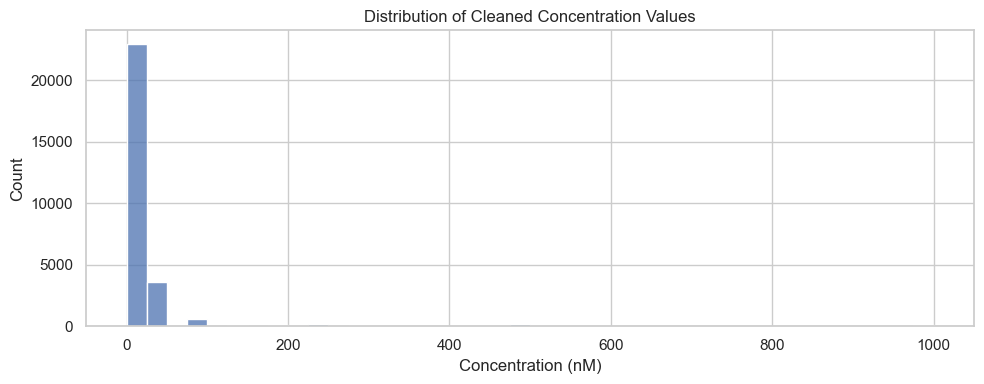

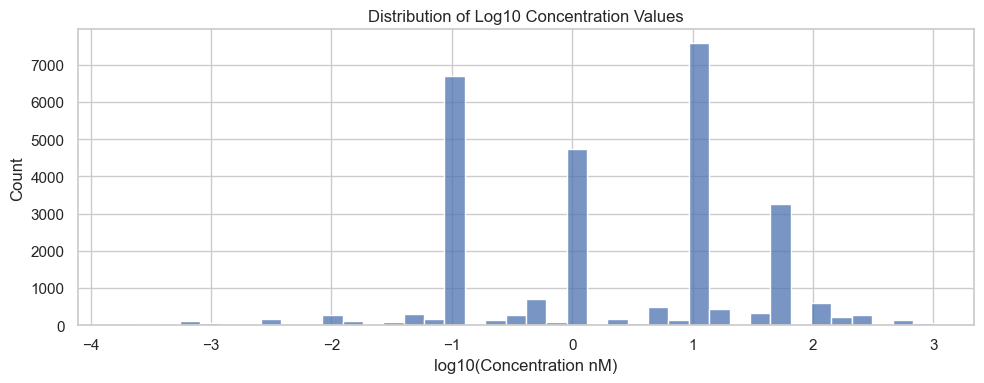

In [5]:
# Plot the cleaned concentration distribution in nM.
plt.figure(figsize=(10, 4))
sns.histplot(df_exp["Concentration_nM"], bins=40)
plt.title("Distribution of Cleaned Concentration Values")
plt.xlabel("Concentration (nM)")
plt.tight_layout()
plt.show()

# Plot the log-transformed concentration distribution, which is often more suitable for modeling.
plt.figure(figsize=(10, 4))
sns.histplot(df_exp["Concentration_log10_nM"], bins=40)
plt.title("Distribution of Log10 Concentration Values")
plt.xlabel("log10(Concentration nM)")
plt.tight_layout()
plt.show()


## 3. Time Encoding

In [6]:
# Standardize the numeric time feature for downstream modeling.
time_mean = df_exp["Time_hours"].mean()
time_std = df_exp["Time_hours"].std()
df_exp["Time_zscore"] = (df_exp["Time_hours"] - time_mean) / time_std

# Create simple presentation-friendly time bins while keeping the numeric time feature for modeling.
df_exp["Time_bin"] = pd.cut(
    df_exp["Time_hours"],
    bins=[0, 24, 48, np.inf],
    labels=["<=24h", "24-48h", ">48h"],
    include_lowest=True,
)

# Display the time encoding results.
display(df_exp[["Time_of_administration", "Time_hours", "Time_zscore", "Time_bin"]].head(15))
display(df_exp["Time_bin"].value_counts(dropna=False).rename("time_bin_count"))


,Time_of_administration,Time_hours,Time_zscore,Time_bin
0,48h,48.0,0.681028,24-48h
1,48h,48.0,0.681028,24-48h
2,48h,48.0,0.681028,24-48h
3,48h,48.0,0.681028,24-48h
4,48h,48.0,0.681028,24-48h
5,48h,48.0,0.681028,24-48h
6,48h,48.0,0.681028,24-48h
7,24h,24.0,-0.481735,<=24h
8,24h,24.0,-0.481735,<=24h
9,24h,24.0,-0.481735,<=24h


Time_bin
<=24h     19450
24-48h     6604
>48h       1751
Name: time_bin_count, dtype: int64

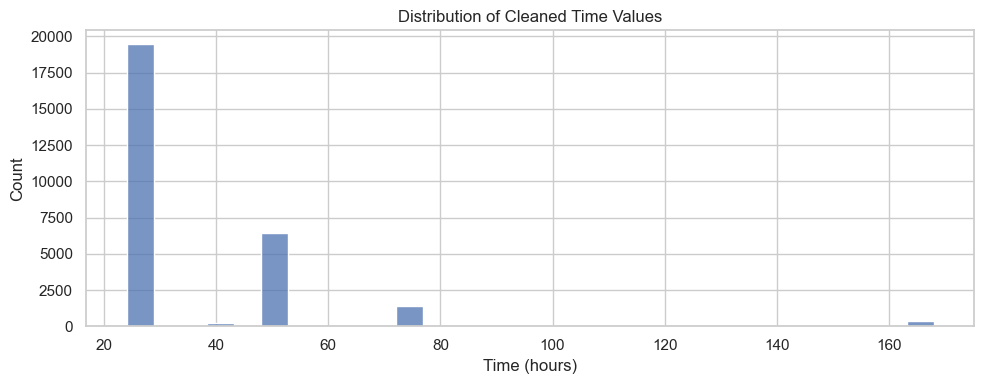

In [7]:
# Plot the cleaned time distribution in hours.
plt.figure(figsize=(10, 4))
sns.histplot(df_exp["Time_hours"], bins=30)
plt.title("Distribution of Cleaned Time Values")
plt.xlabel("Time (hours)")
plt.tight_layout()
plt.show()


## 4. Cell Type Encoding

In [16]:
# One-hot encode the cleaned cell type categories so they can be used directly in a model.
cell_type_ohe = pd.get_dummies(df_exp["Cell_Type_clean"], prefix="cell", dtype=int)

# Join the one-hot columns back onto the experimental dataframe.
df_exp = pd.concat([df_exp, cell_type_ohe], axis=1)

# Display a sample of the encoded cell-type columns.
display(cell_type_ohe.head())
print("Number of one-hot cell-type columns:", cell_type_ohe.shape[1])


,cell_Be(2)C cell line,cell_COS7,cell_HEK293A,cell_HeLa,cell_Hep3B,cell_HepG2,cell_Hepa1-6,cell_Huh7,cell_Human iPSC-derived cortical neurons,cell_Human neuroblastoma Kelly cells(DSMZ),cell_Neuro2A cell line,cell_Non-human hepatocytes,cell_Primary Cynomolgus Monkey Hepatocytes,cell_Primary Macaque Hepatocytes,cell_Primary human hepatocytes,cell_Primary mouse hepatocytes,cell_RT-4,cell_SH-SY5Y cell line
0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Number of one-hot cell-type columns: 18


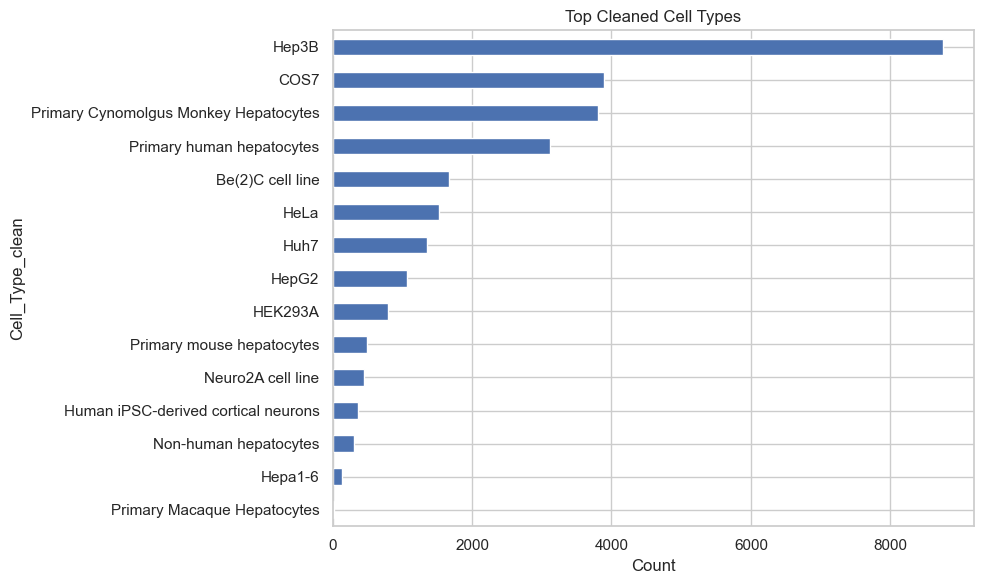

In [17]:
# Plot the most common cleaned cell types for the presentation.
plt.figure(figsize=(10, 6))
df_exp["Cell_Type_clean"].value_counts().head(15).sort_values().plot(kind="barh")
plt.title("Top Cleaned Cell Types")
plt.xlabel("Count")
plt.tight_layout()
plt.show()


## 5. Simple Experimental Quality Flags

In [19]:
# Add a simple flag showing whether an SD value was reported for the experiment.
df_exp["has_sd"] = df_exp["SD"].notna().astype(int)

# Display the SD-availability summary.
display(df_exp["has_sd"].value_counts().rename("has_sd_count"))


has_sd
0    18107
1     9698
Name: has_sd_count, dtype: int64

## 6. Assemble Experimental Feature Table

In [20]:
# Select the key identifiers, cleaned columns, and encoded experimental features into one table.
base_feature_columns = [
    "ID",
    "Target_Gene",
    "Inhibition",
    "Cell_Type_clean",
    "Concentration",
    "Concentration_nM",
    "Concentration_log10_nM",
    "Concentration_zscore",
    "Time_of_administration",
    "Time_hours",
    "Time_zscore",
    "Time_bin",
    "has_sd",
]
experimental_feature_columns = base_feature_columns + cell_type_ohe.columns.tolist()
experimental_features_df = df_exp[experimental_feature_columns].copy()

# Preview the final experimental feature table.
print("Experimental feature table shape:", experimental_features_df.shape)
display(experimental_features_df.head())


Experimental feature table shape: (27805, 103)


,ID,Target_Gene,Inhibition,Cell_Type_clean,Concentration,Concentration_nM,Concentration_log10_nM,Concentration_zscore,Time_of_administration,Time_hours,Time_zscore,Time_bin,has_sd,cell_Be(2)C cell line,cell_Be(2)C cell line,cell_Be(2)C cell line,cell_Be(2)C cell line,cell_Be(2)C cell line,cell_COS7,cell_COS7,cell_COS7,cell_COS7,cell_COS7,cell_HEK293A,cell_HEK293A,cell_HEK293A,cell_HEK293A,cell_HEK293A,cell_HeLa,cell_HeLa,cell_HeLa,cell_HeLa,cell_HeLa,cell_Hep3B,cell_Hep3B,cell_Hep3B,cell_Hep3B,cell_Hep3B,cell_HepG2,cell_HepG2,cell_HepG2,cell_HepG2,cell_HepG2,cell_Hepa1-6,cell_Hepa1-6,cell_Hepa1-6,cell_Hepa1-6,cell_Hepa1-6,cell_Huh7,cell_Huh7,cell_Huh7,cell_Huh7,cell_Huh7,cell_Human iPSC-derived cortical neurons,cell_Human iPSC-derived cortical neurons,cell_Human iPSC-derived cortical neurons,cell_Human iPSC-derived cortical neurons,cell_Human iPSC-derived cortical neurons,cell_Human neuroblastoma Kelly cells(DSMZ),cell_Human neuroblastoma Kelly cells(DSMZ),cell_Human neuroblastoma Kelly cells(DSMZ),cell_Human neuroblastoma Kelly cells(DSMZ),cell_Human neuroblastoma Kelly cells(DSMZ),cell_Neuro2A cell line,cell_Neuro2A cell line,cell_Neuro2A cell line,cell_Neuro2A cell line,cell_Neuro2A cell line,cell_Non-human hepatocytes,cell_Non-human hepatocytes,cell_Non-human hepatocytes,cell_Non-human hepatocytes,cell_Non-human hepatocytes,cell_Primary Cynomolgus Monkey Hepatocytes,cell_Primary Cynomolgus Monkey Hepatocytes,cell_Primary Cynomolgus Monkey Hepatocytes,cell_Primary Cynomolgus Monkey Hepatocytes,cell_Primary Cynomolgus Monkey Hepatocytes,cell_Primary Macaque Hepatocytes,cell_Primary Macaque Hepatocytes,cell_Primary Macaque Hepatocytes,cell_Primary Macaque Hepatocytes,cell_Primary Macaque Hepatocytes,cell_Primary human hepatocytes,cell_Primary human hepatocytes,cell_Primary human hepatocytes,cell_Primary human hepatocytes,cell_Primary human hepatocytes,cell_Primary mouse hepatocytes,cell_Primary mouse hepatocytes,cell_Primary mouse hepatocytes,cell_Primary mouse hepatocytes,cell_Primary mouse hepatocytes,cell_RT-4,cell_RT-4,cell_RT-4,cell_RT-4,cell_RT-4,cell_SH-SY5Y cell line,cell_SH-SY5Y cell line,cell_SH-SY5Y cell line,cell_SH-SY5Y cell line,cell_SH-SY5Y cell line
0,001-01-01-00001-100n-48h-88.00,CTNNB1,88.0,HeLa,100nM,100.0,2.0,1.500988,48h,48.0,0.681028,24-48h,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,001-01-01-00002-100n-48h-90.00,CTNNB1,90.0,HeLa,100nM,100.0,2.0,1.500988,48h,48.0,0.681028,24-48h,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,001-01-01-00003-100n-48h-90.00,CTNNB1,90.0,HeLa,100nM,100.0,2.0,1.500988,48h,48.0,0.681028,24-48h,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,001-01-01-00004-100n-48h-89.00,CTNNB1,89.0,HeLa,100nM,100.0,2.0,1.500988,48h,48.0,0.681028,24-48h,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,001-01-01-00005-100n-48h-87.00,CTNNB1,87.0,HeLa,100nM,100.0,2.0,1.500988,48h,48.0,0.681028,24-48h,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 7. Save Encoded Outputs

In [21]:
# Create the output folder if it does not already exist.
processed_dir.mkdir(parents=True, exist_ok=True)

# Save the encoded experimental feature table and the full dataframe with encoded columns.
experimental_features_df.to_csv(processed_dir / "CMsiRNA_experimental_features.tsv", sep="\t", index=False)
df_exp.to_csv(processed_dir / "CMsiRNA_qc_with_experimental_encoding.tsv", sep="\t", index=False)

# Confirm where the outputs were written.
print("Saved experimental feature outputs to:", processed_dir)


Saved experimental feature outputs to: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed
